# PV NPV simulation

Run the PV electricity Monte Carlo simulation and visualize the resulting NPV distribution.

The summary also reports how many simulations have non-negative NPV (NPV >= 0) and how many have negative NPV.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_results,
)

from npv_summary import summarize_metric_signs


In [2]:
TECHNOLOGY = 'pv'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

results_by_technology = simulate_electricity_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,lifetime_years,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,...,initial_capex_eur,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_mwh,levelized_net_margin_eur_per_mwh
0,0,pv,1000000.0,1107.5,30.0,902.934537,902934.537246,894.491750,13.684828,0.0,...,8.076675e+08,94070000.0,1.235650e+07,0.0,0.0,0.0,8.171350e+07,1.122453e+08,1.125778e+07,9.970466
1,1,pv,1000000.0,1107.5,30.0,902.934537,902934.537246,899.290622,12.937581,0.0,...,8.120006e+08,94070000.0,1.168179e+07,0.0,0.0,0.0,8.238821e+07,1.155081e+08,1.125778e+07,10.260285
2,2,pv,1000000.0,1107.5,30.0,902.934537,902934.537246,728.540430,13.498696,0.0,...,6.578243e+08,94070000.0,1.218844e+07,0.0,0.0,0.0,8.188156e+07,2.639806e+08,1.125778e+07,23.448715
3,3,pv,1000000.0,1107.5,30.0,902.934537,902934.537246,701.314447,12.889968,0.0,...,6.332410e+08,94070000.0,1.163880e+07,0.0,0.0,0.0,8.243120e+07,2.947516e+08,1.125778e+07,26.182027
4,4,pv,1000000.0,1107.5,30.0,902.934537,902934.537246,762.280512,15.456266,0.0,...,6.882894e+08,94070000.0,1.395600e+07,0.0,0.0,0.0,8.011400e+07,2.136167e+08,1.125778e+07,18.975023


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
levelized_net_margin_eur_per_mwh = results["levelized_net_margin_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        levelized_net_margin_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "Levelized net margin EUR/MWh"
        ),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,Levelized net margin EUR/MWh
count,100000.000000,100000.000000
mean,196.961359,17.495572
std,53.925980,4.790106
min,72.209842,6.414215
5%,112.480394,9.991345
50%,197.198029,17.516595
95%,281.536348,25.008151
max,317.361829,28.190437


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),100000,1.0
1,Negative (NPV < 0),0,0.0


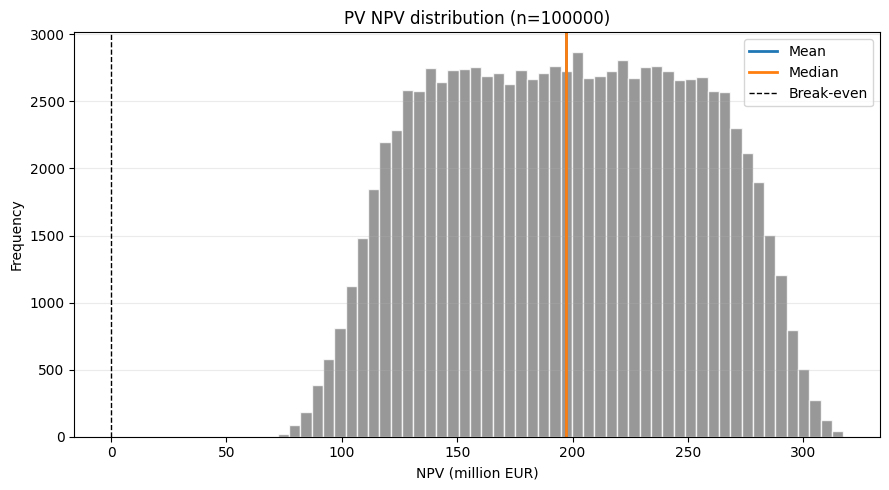

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"PV NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## levelized net margin histogram


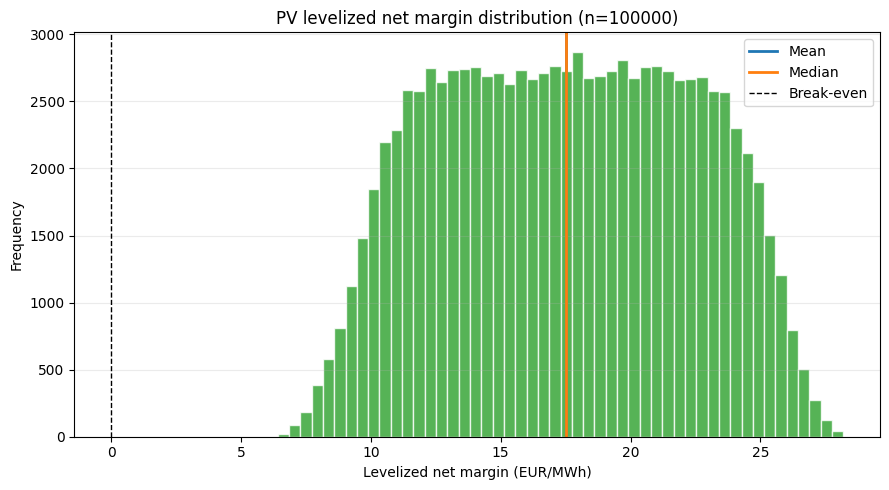

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    levelized_net_margin_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    levelized_net_margin_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    levelized_net_margin_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"PV levelized net margin distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("Levelized net margin (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.07000
annual_fixed_opex_eur        12.40026
annual_variable_opex_eur      0.00000
annual_fuel_cost_eur          0.00000
annual_emissions_cost_eur     0.00000
annual_net_cash_flow_eur     81.66974
Name: Mean annual value, million EUR, dtype: float64